In [1]:
import os
import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


current_dir = os.getcwd()

# 1. Link GCAD
gcad_engine_dir = os.path.join(current_dir, 'GCAD')
if gcad_engine_dir not in sys.path:
    sys.path.append(gcad_engine_dir)
import define_circuit

from active_learning_loop._designer import ExperimentDesigner
from active_learning_loop._lab import VirtualLab
from active_learning_loop._learner import Learner

# 2. Load Circuits
with open(os.path.join(current_dir, 'selected_M_circuits.pkl'), 'rb') as f:
    circuits_list = pickle.load(f)
circuit_dict = {f"Circuit_{i+1}": c for i, c in enumerate(circuits_list)}

# 3. Load Prior Belief Cloud
al_memory_dir = os.path.join(current_dir, 'active_learning_loop', 'al_memory')
with open(os.path.join(al_memory_dir, 'prior_belief_cloud_N200_spread2.0.pkl'), 'rb') as f: # Update name if needed!
    belief_cloud = pickle.load(f)

# 4. Load Parameters (Nominal Promos & TRUE Lab Parts)
with open(os.path.join(current_dir, 'GCAD', 'promo.pkl'), 'rb') as f:
    promo_params = pickle.load(f)
with open(os.path.join(current_dir, 'ground_truth', 'true_parts.pkl'), 'rb') as f:
    true_parts = pickle.load(f)

print("✅ All data loaded.")

✅ All data loaded.


In [2]:
# Fix Randomness for Reproducibility
np.random.seed(42)

# Initialize Virtual Lab
lab = VirtualLab(circuit_dict=circuit_dict, 
                 true_universal_params=true_parts, 
                 true_promo_params=promo_params, 
                 noise_level=0.02)

# Initialize Designer
DOSAGES = np.arange(0.2, 4.2, 0.2)
designer = ExperimentDesigner(circuit_dict=circuit_dict, 
                              candidate_dosages=DOSAGES, 
                              variance_metric="time_specific", 
                              p_circuits=2, q_dosages=2)

# Initialize Learner (The Inference Engine)
# Set perturbation to 0.15 for faster gradient descent
learner = Learner(circuit_dict=circuit_dict, 
                  selection_ratio=0.2, 
                  perturbation_scale=0.15) 

print("✅ Lab, Designer, and Learner initialized.")

[Learner Init] Tracking and optimizing only active parts: {'I13', 'Z6'}
✅ Lab, Designer, and Learner initialized.


In [3]:
MAX_CYCLES = 10
CV_THRESHOLD = 0.1
t_span = np.arange(0, 126, 1)

history = {'max_uncertainty': [], 'best_nmse': [], 'max_cv': [], 'learning_rate': []}
global_lab_data_dict = {} 

def check_convergence(ensemble, threshold):
    all_cvs = []
    # We only track the spread of the parameters we are actually mutating
    targets = {'Z6': [0, 1], 'I13': [0]}
    
    for part, indices in targets.items():
        for idx in indices:
            # Extract just this specific number across all 300 models
            stacked = np.array([model[part][idx] for model in ensemble]) 
            std_dev = np.std(stacked)
            mean_val = np.mean(stacked)
            cv = np.abs(std_dev / (mean_val + 1e-9))
            all_cvs.append(cv)
            
    return np.max(all_cvs) < threshold, np.max(all_cvs)

cycle = 0
converged = False

while not converged and cycle < MAX_CYCLES:
    print(f"\n" + "="*40)
    print(f" 🚀 STARTING AL CYCLE {cycle}")
    print("="*40)
    
    # ---> Simulated Annealing (Decaying Learning Rate) <---
    # Starts at ~15% noise, decays by 15% each cycle, stops decaying at 1%
    current_noise = max(0.01, 0.15 * (0.85 ** cycle))
    learner.perturbation_scale = current_noise
    history['learning_rate'].append(current_noise)
    print(f"🌡️ Current Noise Level: {current_noise:.1%}")
    
    # ---------------------------------------------------------
    # 1. DESIGN PHASE
    # ---------------------------------------------------------
    if cycle == 0:
        print("[Designer] Loading pre-computed decisions for Cycle 0...")
        decision_path = os.path.join(al_memory_dir, 'designer_decisions_time_specific_cycle_0.pkl')
        with open(decision_path, 'rb') as f:
            cycle_0_data = pickle.load(f)
        selected_experiments = cycle_0_data['selected_experiments']
        max_u = np.max(cycle_0_data['variance_matrix'])
    else:
        print("[Designer] Simulating current belief ensemble to find best experiments...")
        selected_experiments, _, _, max_u, _ = designer.design_experiment(belief_cloud, promo_params)
    
    history['max_uncertainty'].append(max_u)
    print(f"[Designer] Selected Experiments: {selected_experiments}")
    
    # ---------------------------------------------------------
    # 2. LAB PHASE
    # ---------------------------------------------------------
    print("\n[Lab] Running requested experiments...")
    for (c_name, dose) in selected_experiments:
        if (c_name, dose) not in global_lab_data_dict:
            _, y_noisy = lab.run_experiment(c_name, dose, t_span)
            global_lab_data_dict[(c_name, dose)] = y_noisy
            
    # ---------------------------------------------------------
    # 3. LEARNER PHASE
    # ---------------------------------------------------------
    print("\n[Learner] Updating parameter belief ensemble...")
    belief_cloud, best_error = learner.update_belief(
        current_ensemble=belief_cloud, 
        promo_params=promo_params, 
        lab_data_dict=global_lab_data_dict,
        t_span=t_span
    )
    history['best_nmse'].append(best_error)
    
    # ---------------------------------------------------------
    # 4. CONVERGENCE CHECK
    # ---------------------------------------------------------
    converged, current_max_cv = check_convergence(belief_cloud, CV_THRESHOLD)
    history['max_cv'].append(current_max_cv)
    
    print(f"✅ Cycle {cycle} Complete. Max Parameter Spread: {current_max_cv:.1%} (Target: < {CV_THRESHOLD:.1%})")
    cycle += 1

print("\n🎉 ACTIVE LEARNING LOOP FINISHED.")

# ---------------------------------------------------------
# 5. EXTRACT THE MEAN
# ---------------------------------------------------------
final_mean_parameters = {}
for key in belief_cloud[0].keys():
    stacked = np.array([model[key] for model in belief_cloud])
    final_mean_parameters[key] = np.mean(stacked, axis=0)

print("\n🎯 FINAL DISCOVERED PARAMETERS (Mean of Posterior):")
print(f"   Z6:  {final_mean_parameters['Z6']}")
print(f"   I13: {final_mean_parameters['I13']}")


 🚀 STARTING AL CYCLE 0
🌡️ Current Noise Level: 15.0%
[Designer] Loading pre-computed decisions for Cycle 0...
[Designer] Selected Experiments: [('Circuit_3', 2.2), ('Circuit_3', 2.4000000000000004), ('Circuit_1', 1.8), ('Circuit_1', 1.6)]

[Lab] Running requested experiments...

[Learner] Updating parameter belief ensemble...

--- [Learner] Assessing 200 models against 4 experiments ---


Evaluating Models: 100%|██████████| 200/200 [00:46<00:00,  4.26model/s]


[Learner] Selected top 40 candidates.
[Learner] Best Total NMSE: 1.4206e-03 (across 4 exps)
✅ Cycle 0 Complete. Max Parameter Spread: 40.7% (Target: < 10.0%)

 🚀 STARTING AL CYCLE 1
🌡️ Current Noise Level: 12.8%
[Designer] Simulating current belief ensemble to find best experiments...


Simulating 2D Grid: 100%|██████████| 60/60 [17:16<00:00, 17.28s/exp]


[Designer] Selected Experiments: [('Circuit_1', 4.0), ('Circuit_1', 3.8000000000000003), ('Circuit_3', 4.0), ('Circuit_3', 3.8000000000000003)]

[Lab] Running requested experiments...

[Learner] Updating parameter belief ensemble...

--- [Learner] Assessing 200 models against 8 experiments ---


...

[Learner] Selected top 40 candidates.
[Learner] Best Total NMSE: 2.4170e-02 (across 14 exps)
✅ Cycle 8 Complete. Max Parameter Spread: 48.1% (Target: < 10.0%)

 🚀 STARTING AL CYCLE 9
🌡️ Current Noise Level: 3.5%
[Designer] Simulating current belief ensemble to find best experiments...


Simulating 2D Grid: 100%|██████████| 60/60 [12:48<00:00, 12.81s/exp]


[Designer] Selected Experiments: [('Circuit_2', 2.6000000000000005), ('Circuit_2', 2.8000000000000003), ('Circuit_3', 4.0), ('Circuit_3', 3.8000000000000003)]

[Lab] Running requested experiments...

[Learner] Updating parameter belief ensemble...

--- [Learner] Assessing 200 models against 15 experiments ---


Evaluating Models: 100%|██████████| 200/200 [03:45<00:00,  1.13s/model]

[Learner] Selected top 40 candidates.
[Learner] Best Total NMSE: 1.2692e-02 (across 15 exps)
✅ Cycle 9 Complete. Max Parameter Spread: 46.0% (Target: < 10.0%)

🎉 ACTIVE LEARNING LOOP FINISHED.

🎯 FINAL DISCOVERED PARAMETERS (Mean of Posterior):
   Z6:  [1.80067541e-02 7.02733896e+01 4.30000000e-02]
   I13: [0.00904796]


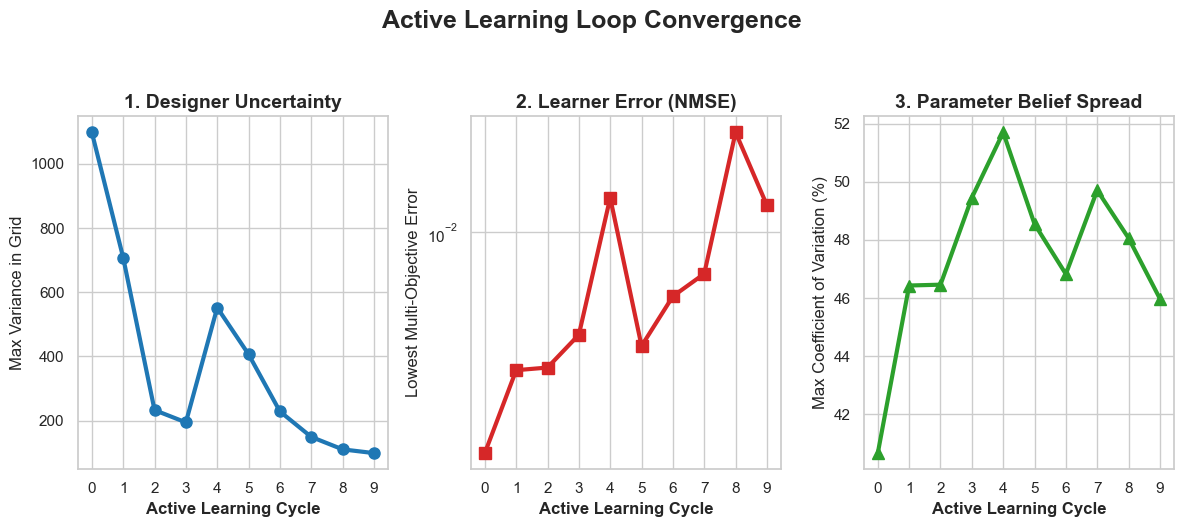

In [16]:
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
cycles_array = np.arange(len(history['max_uncertainty']))

# Panel 1: Designer Uncertainty
axes[0].plot(cycles_array, history['max_uncertainty'], marker='o', markersize=8, color='#1f77b4', linewidth=3)
axes[0].set_title('1. Designer Uncertainty', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Active Learning Cycle', fontweight='bold')
axes[0].set_ylabel('Max Variance in Grid')
axes[0].set_xticks(cycles_array)

# Panel 2: Learner Error (NMSE)
axes[1].plot(cycles_array, history['best_nmse'], marker='s', markersize=8, color='#d62728', linewidth=3)
axes[1].set_title('2. Learner Error (NMSE)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Active Learning Cycle', fontweight='bold')
axes[1].set_ylabel('Lowest Multi-Objective Error')
axes[1].set_yscale('log') 
axes[1].set_xticks(cycles_array)

# Panel 3: Ensemble Spread
axes[2].plot(cycles_array, [cv * 100 for cv in history['max_cv']], marker='^', markersize=8, color='#2ca02c', linewidth=3)
axes[2].set_title('3. Parameter Belief Spread', fontweight='bold', fontsize=14)
axes[2].set_xlabel('Active Learning Cycle', fontweight='bold')
axes[2].set_ylabel('Max Coefficient of Variation (%)')
axes[2].set_xticks(cycles_array)

plt.suptitle("Active Learning Loop Convergence", fontsize=18, fontweight='heavy', y=1.05)
plt.tight_layout()
plt.show()

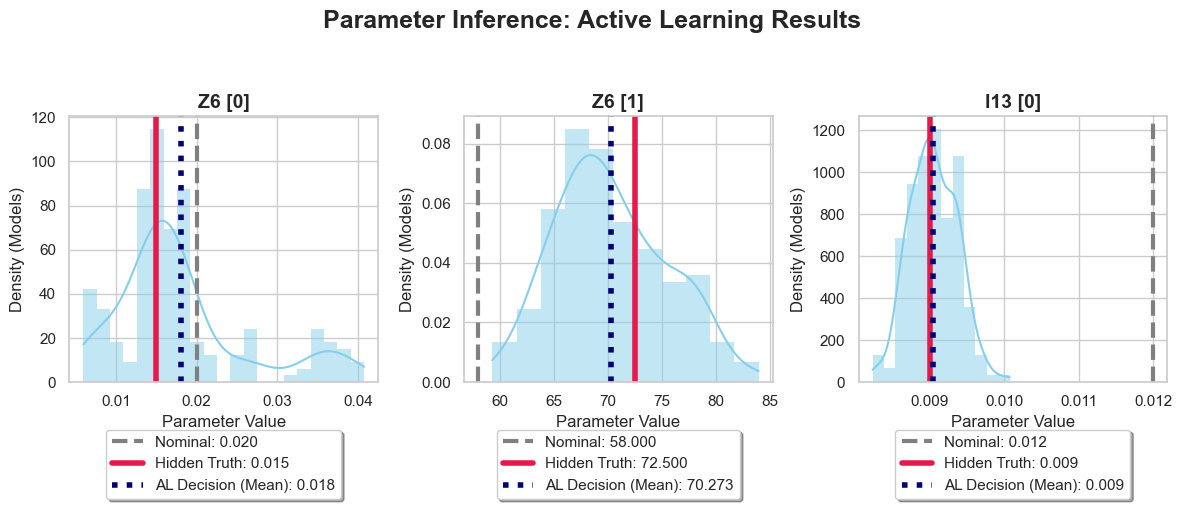

✅ Saved Final Posterior Belief to 'c:\Users\KuangQi\Desktop\GCAD-SDL\GCAD-SDL\Self_Calibrating_Loop\active_learning_loop\al_memory\final_posterior_belief.pkl'.


In [15]:
# The specific parameters we mutated
params_to_plot = [
    ('Z6', 0, 'Z6 [0]'),
    ('Z6', 1, 'Z6 [1]'),
    ('I13', 0, 'I13 [0]')
]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Load Nominal (Textbook) Parameters
with open(os.path.join(current_dir, 'GCAD', 'parts_nominal_backup.pkl'), 'rb') as f:
    nominal_parts = pickle.load(f)

for i, (part, idx, title) in enumerate(params_to_plot):
    ax = axes[i]
    nominal_val = nominal_parts[part][idx]
    true_val = true_parts[part][idx]
    
    # Extract the posterior distribution from the final ensemble
    posterior_dist = np.array([model[part][idx] for model in belief_cloud])
    
    sns.histplot(posterior_dist, ax=ax, color='skyblue', kde=True, stat="density", linewidth=0)
    
    ax.axvline(nominal_val, color='gray', linestyle='--', linewidth=3, label=f"Nominal: {nominal_val:.3f}")
    ax.axvline(true_val, color='#e6194B', linestyle='-', linewidth=4, label=f"Hidden Truth: {true_val:.3f}")
    
    final_mean = np.mean(posterior_dist)
    ax.axvline(final_mean, color='#000075', linestyle=':', linewidth=4, label=f"AL Decision (Mean): {final_mean:.3f}")
    
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_xlabel('Parameter Value')
    ax.set_ylabel('Density (Models)')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=1)

plt.suptitle("Parameter Inference: Active Learning Results", fontsize=18, fontweight='heavy', y=1.05)
plt.tight_layout()
plt.show()

# Save final parameter set for the GCAD re-run step
posterior_path = os.path.join(al_memory_dir, 'final_posterior_belief.pkl')
with open(posterior_path, 'wb') as f:
    pickle.dump(belief_cloud, f)
print(f"✅ Saved Final Posterior Belief to '{posterior_path}'.")

--- SIMULATING PHENOTYPIC COMPARISON ---


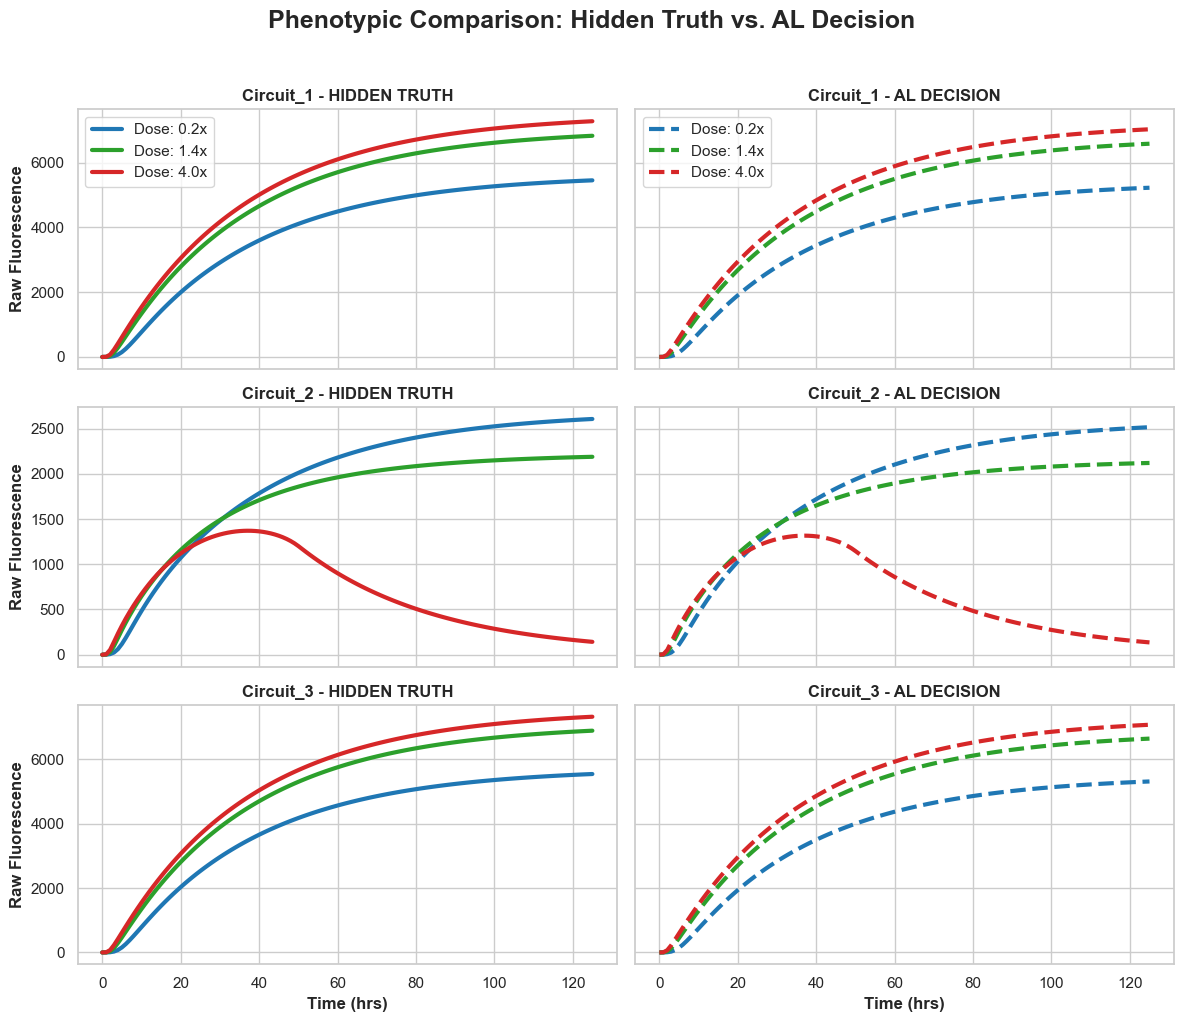

In [17]:
import copy
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import sys

current_dir = os.getcwd()
gcad_dir = os.path.join(current_dir, 'GCAD')
if gcad_dir not in sys.path:
    sys.path.append(gcad_dir)

try:
    from GCAD.get_system_equations_pop import system_equations_DsRed_pop
    from GCAD.define_circuit import Topo
except ImportError:
    # Fallback depending on how the path resolved
    from get_system_equations_pop import system_equations_DsRed_pop
    from define_circuit import Topo

print("--- SIMULATING PHENOTYPIC COMPARISON ---")

# 1. Build a full dictionary for the AI Discovered parts
with open(os.path.join(current_dir, 'GCAD', 'parts.pkl'), 'rb') as f:
    discovered_parts = pickle.load(f)
for k, v in final_mean_parameters.items():
    discovered_parts[k] = v

# 2. Setup the Dosages and Plotting Grid
test_dosages = [0.2, 1.4, 4.0]
colors = ['#1f77b4', '#2ca02c', '#d62728'] # Blue, Green, Red

# sharey='row' ensures the Y-axis limits are identical between Truth and Discovered
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True, sharey='row')

for row_idx, (c_name, topology) in enumerate(circuit_dict.items()):
    ax_truth = axes[row_idx, 0]
    ax_disc = axes[row_idx, 1]
    
    for d_idx, dose in enumerate(test_dosages):
        # Apply dosage
        sim_dose = {k: v * dose for k, v in topology.dose.items() if k != 'Rep'}
        if 'Rep' in topology.dose: sim_dose['Rep'] = topology.dose['Rep']
        temp_topo = Topo(topology.edge_list, sim_dose, topology.promo_node)
        
        # Simulate Truth (Left Column)
        y_raw_truth = odeint(
            system_equations_DsRed_pop, np.zeros(temp_topo.num_states * 2), t_span,
            args=('on', np.ones(5), temp_topo, promo_params, true_parts)
        )[:, -1]
        
        # Simulate AI Discovered (Right Column)
        y_raw_disc = odeint(
            system_equations_DsRed_pop, np.zeros(temp_topo.num_states * 2), t_span,
            args=('on', np.ones(5), temp_topo, promo_params, discovered_parts)
        )[:, -1]
        
        # Plot
        ax_truth.plot(t_span, y_raw_truth, label=f"Dose: {dose}x", color=colors[d_idx], lw=3)
        ax_disc.plot(t_span, y_raw_disc, label=f"Dose: {dose}x", color=colors[d_idx], lw=3, linestyle='--')
        
    # Formatting
    ax_truth.set_title(f"{c_name} - HIDDEN TRUTH", fontweight='bold', fontsize=12)
    ax_disc.set_title(f"{c_name} - AL DECISION", fontweight='bold', fontsize=12)
    ax_truth.set_ylabel("Raw Fluorescence", fontweight='bold')
    
    # Add legends only to the top row
    if row_idx == 0:
        ax_truth.legend(loc='upper left')
        ax_disc.legend(loc='upper left')

axes[2, 0].set_xlabel("Time (hrs)", fontweight='bold')
axes[2, 1].set_xlabel("Time (hrs)", fontweight='bold')
plt.suptitle("Phenotypic Comparison: Hidden Truth vs. AL Decision", fontsize=18, fontweight='heavy', y=1.02)
plt.tight_layout()
plt.show()